# 🏨 Dynamic Hotel Pricing Optimization

## 📊 01_EDA - Exploratory Data Analysis

**Goal:** Explore the dataset, understand key patterns and prepare
features for modeling.

In [1]:
# 1️⃣ Load Data
import pandas as pd

df = pd.read_csv('../data/raw/hotel_bookings.csv')

df.shape
df.head()


5 rows × 32 columns

In [2]:
# 2️⃣ Data Summary
df.info()

df.isnull().sum()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [3]:
# 3️⃣ Feature Engineering
df['stay_length'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['booking_month'] = pd.to_datetime(df['reservation_status_date']).dt.month
df['weekday'] = pd.to_datetime(df['reservation_status_date']).dt.weekday

df[['stay_length', 'lead_time', 'booking_month', 'weekday']].head()


Matplotlib is building the font cache; this may take a moment.

Cancellation Rate: 37.04%

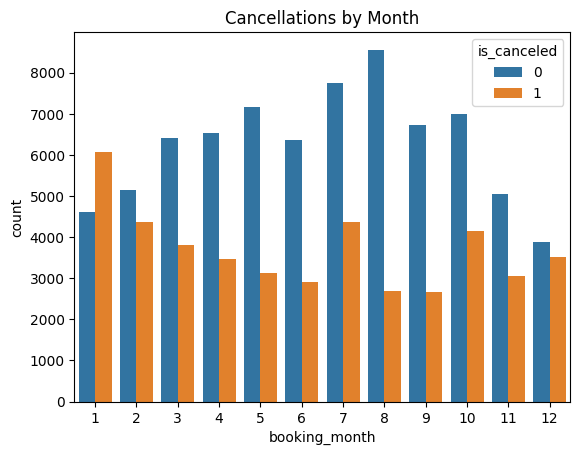

In [4]:
# 4️⃣ Target Exploration - Cancellations
import seaborn as sns
import matplotlib.pyplot as plt

cancel_rate = df['is_canceled'].mean()
print(f"Cancellation Rate: {cancel_rate:.2%}")

sns.countplot(data=df, x='booking_month', hue='is_canceled')
plt.title('Cancellations by Month')
plt.show()


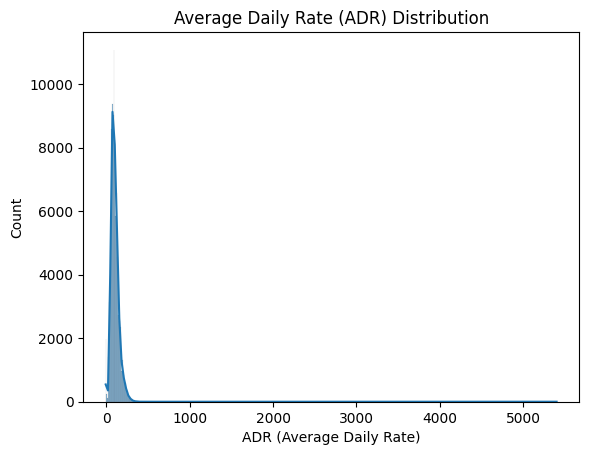

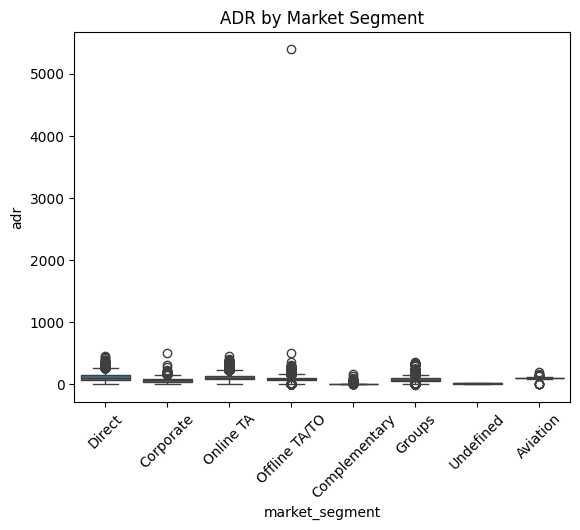

In [5]:
# 5️⃣ Price Analysis
sns.histplot(df['adr'], kde=True)
plt.title('Average Daily Rate (ADR) Distribution')
plt.xlabel('ADR (Average Daily Rate)')
plt.show()

sns.boxplot(data=df, x='market_segment', y='adr')
plt.xticks(rotation=45)
plt.title('ADR by Market Segment')
plt.show()


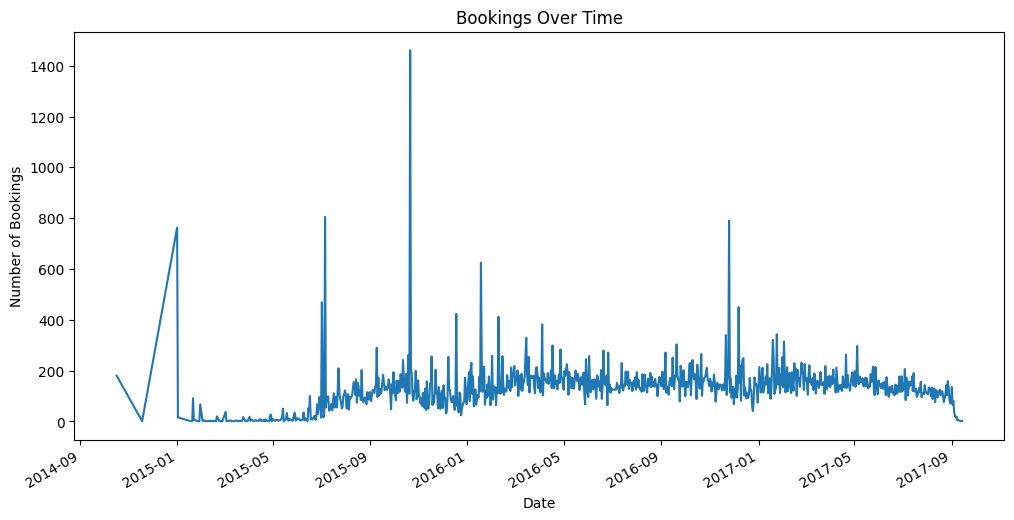

In [6]:
# 6️⃣ Booking Patterns
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
bookings_by_date = df.groupby('reservation_status_date').size()

bookings_by_date.plot(figsize=(12,6))
plt.title('Bookings Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Bookings')
plt.show()
